# Forecasting

In this assignment, we will explore the python package [statsmodels](http://www.statsmodels.org/dev/tsa.html) to forecast the time series data. You will learn to use different time series modeling technique for forecasting.

Learning Objectives:

- Decompose time series into autocorrelation, seasonality, trend, and noise. 
- Explain the effects of exponential smoothing models and differentiate them from other models.
- Apply and evaluate the results of an autoregressive model. 
- Apply and evaluate the results of a moving average model. 
- Apply and evaluate the results of an autoregressive integrated moving average model.
- Apply and evaluate the results of ARIMA model for forecasting (time series prediction).


In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from math import sqrt
import warnings
warnings.filterwarnings('ignore')

----------

## Air Passenger Dataset
This dataset provides monthly totals of international airline passengers from 1949 to 1960. You can find a copy of the dataset on [Kaggle](https://www.kaggle.com/rakannimer/air-passengers) or [R datasets](https://stat.ethz.ch/R-manual/R-devel/library/datasets/html/AirPassengers.html).

In [2]:
from pylab import rcParams
rcParams['figure.figsize'] = 10,10

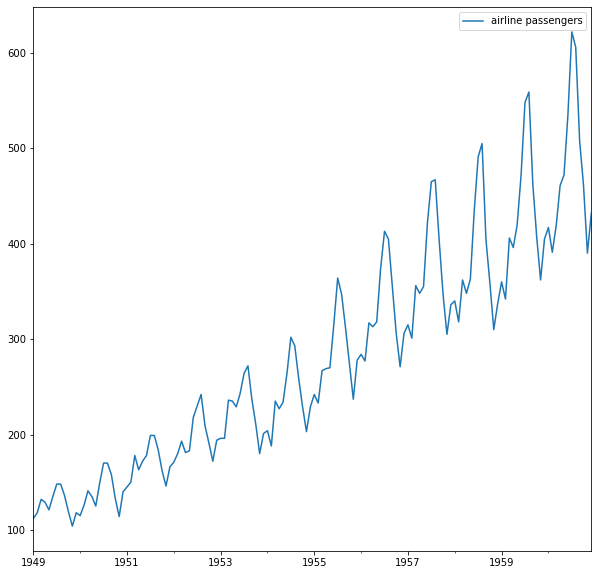

In [3]:
df = pd.read_csv('./airline-passengers.csv', index_col=[0], parse_dates=True)
df.index = pd.DatetimeIndex(df.index.values, freq=df.index.inferred_freq)

# split the data into train and test
train, test = df.iloc[:130, [0]], df.iloc[130:, [0]]
df.plot()
pyplot.show()

## Question 1.1: Using [seasonal_decompose](https://www.statsmodels.org/stable/generated/statsmodels.tsa.seasonal.seasonal_decompose.html) API from `statsmodels.tsa.seasonal`, apply additive decomposition to the airline passenger dataset and plot each components from the decomposition.

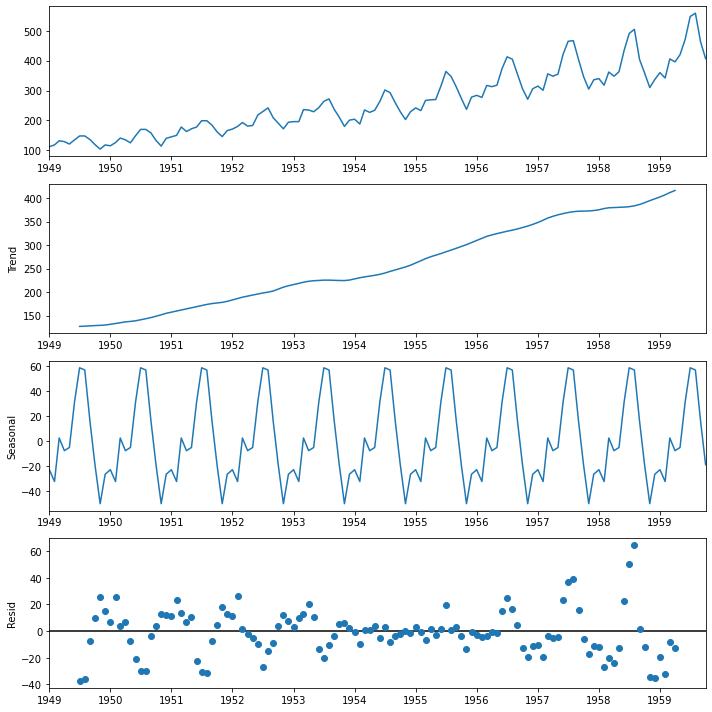

In [4]:
# additive decomposition
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(train, model="additive")
result.plot()
pyplot.show()

## Question 1.2: Using [seasonal_decompose](https://www.statsmodels.org/stable/generated/statsmodels.tsa.seasonal.seasonal_decompose.html) API from `statsmodels.tsa.seasonal`, apply multiplication decomposition to the same airline passenger dataset and plot each components from the decomposition. Which decomposition makes more sense in this dataset? 

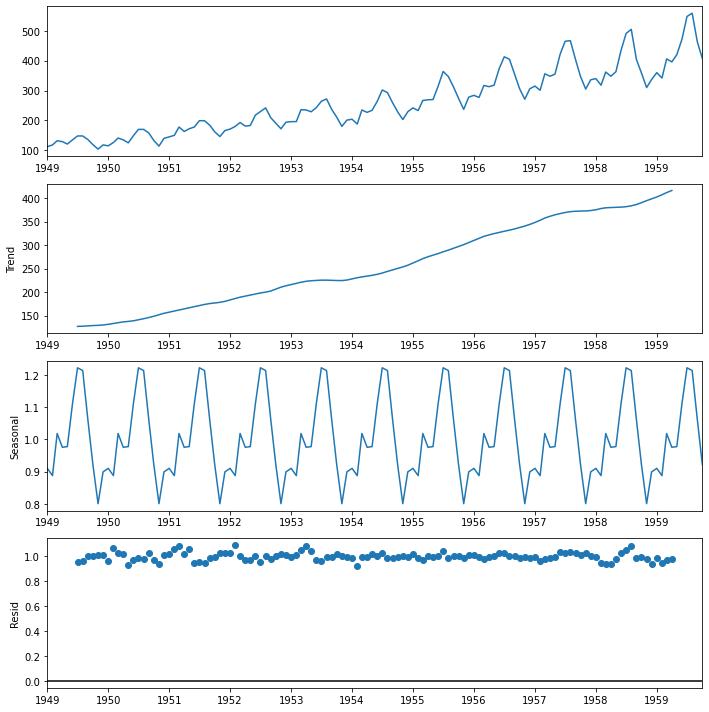

In [5]:
# multiplicative decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(train, model="multiplicative")
result.plot()
pyplot.show()

#### It seems that the additive decomposition has a clear advantage when you view the Residuals plot, the values are all reasonable distributed and a siginifigant fraction are small whereas the values for the multiplicative decomposition are oddly constant, show little variation, and are relatively large.

----------

## Question 2.1: Apply the simple exponential smoothing technique ([SimpleExpSmoothing](https://www.statsmodels.org/dev/generated/statsmodels.tsa.holtwinters.SimpleExpSmoothing.html) API) to the airline dataset and report the prediction accuracy (RMSE and MAE) on the test dataset. Try to play around with the hyper-parameter `smoothing_level` and see how it impacts the model accuracy. 

In [6]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# fit model
fit1 = SimpleExpSmoothing(train).fit(smoothing_level=0.2)
fit2 = SimpleExpSmoothing(train).fit(smoothing_level=0.6)
fit3 = SimpleExpSmoothing(train).fit()

In [7]:
pred1 = fit1.fittedvalues
pred2 = fit2.fittedvalues
pred3 = fit3.fittedvalues

In [8]:
preds = [pred1, pred2, pred3]
true  = [train[:-1], train[:-2], train[:-3]]
fits  = [fit1, fit2, fit3]
for i in range(3):
    print("Fit ",i+1,"| \t Alpha:",fits[i].params["smoothing_level"])
    print()
    print("rmse: " + str(sqrt(mean_squared_error(train,preds[i])))) 
    print(" mae: " + str(mean_absolute_error(train,preds[i])))
    print()

Fit  1 | 	 Alpha: 0.2

rmse: 43.38585991640613
 mae: 31.521285768950985

Fit  2 | 	 Alpha: 0.6

rmse: 36.09481812140578
 mae: 27.087089222703565

Fit  3 | 	 Alpha: 0.9999999850988388

rmse: 30.975052131429976
 mae: 23.592307809146135



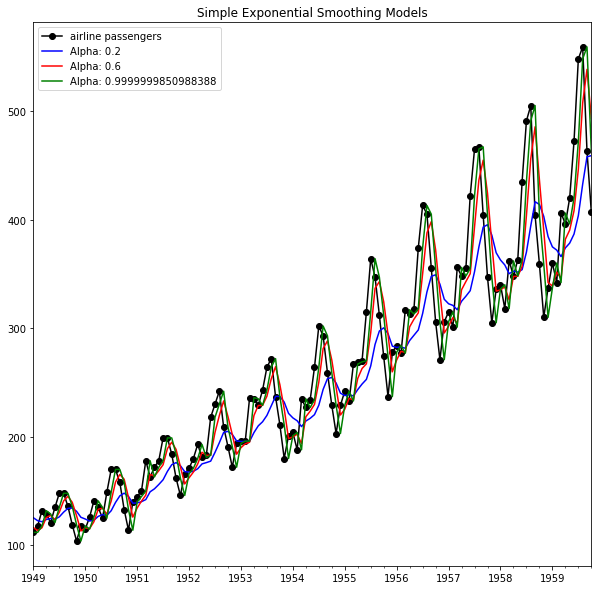

In [9]:
import matplotlib.pyplot as plt

train.plot(color='black', marker="o", label="train", legend=True)

fit1.fittedvalues.plot(color='blue',  label="Alpha: "+str(fit1.params["smoothing_level"]), legend=True)
fit2.fittedvalues.plot(color='red',   label="Alpha: "+str(fit2.params["smoothing_level"]), legend=True)
fit3.fittedvalues.plot(color='green', label="Alpha: "+str(fit3.params["smoothing_level"]), legend=True)

plt.title("Simple Exponential Smoothing Models")
plt.show()

----------

## Question 2.2: Apply the HWES technique ([ExponentialSmoothing](https://www.statsmodels.org/dev/generated/statsmodels.tsa.holtwinters.ExponentialSmoothing.html) API) to the airline dataset and report the prediction accuracy (RMSE and MAE) on the test dataset. Try to play around with the hyper-parameters in the API and see how it impacts the model accuracy. 

In [10]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# fit model
fit1 = ExponentialSmoothing(train).fit(smoothing_level=0.1, smoothing_trend=0.1, smoothing_seasonal=0.1)
fit2 = ExponentialSmoothing(train).fit(smoothing_level=0.6, smoothing_trend=0.3, smoothing_seasonal=0.2)
fit3 = ExponentialSmoothing(train).fit(smoothing_level=0.3, smoothing_trend=0.3, smoothing_seasonal=0.3)
fit4 = ExponentialSmoothing(train).fit(smoothing_level=0.6, smoothing_trend=0.6, smoothing_seasonal=0.6)
fit5 = ExponentialSmoothing(train).fit(smoothing_trend=0.5, smoothing_seasonal=0.5)
fit6 = ExponentialSmoothing(train).fit(smoothing_trend=0.7, smoothing_seasonal=0.7)

# make prediction
pred1 = fit1.fittedvalues
pred2 = fit2.fittedvalues
pred3 = fit3.fittedvalues
pred4 = fit4.fittedvalues
pred5 = fit5.fittedvalues
pred6 = fit6.fittedvalues


preds = [pred1, pred2, pred3, pred4, pred5, pred6]
fits  = [fit1, fit2, fit3, fit4, fit5, fit6]
for i in range(6):
    print("Fit ",i+1,"| \t Alpha:",fits[i].params["smoothing_level"],"\t Beta:", fits[i].params["smoothing_trend"],"\t Gamma:", fits[i].params["smoothing_seasonal"])
    print()
    print("rmse: \t" + str(sqrt(mean_squared_error(train,preds[i])))) 
    print(" mae: \t" + str(mean_absolute_error(train,preds[i])))
    print()

Fit  1 | 	 Alpha: 0.1 	 Beta: 0.1 	 Gamma: 0.1

rmse: 	48.1939721259503
 mae: 	34.364494809027754

Fit  2 | 	 Alpha: 0.6 	 Beta: 0.3 	 Gamma: 0.2

rmse: 	36.0948181214057
 mae: 	27.087089291756197

Fit  3 | 	 Alpha: 0.3 	 Beta: 0.3 	 Gamma: 0.3

rmse: 	41.41149502196789
 mae: 	30.542490643096528

Fit  4 | 	 Alpha: 0.6 	 Beta: 0.6 	 Gamma: 0.6

rmse: 	36.0948181214057
 mae: 	27.087089291756197

Fit  5 | 	 Alpha: 0.995 	 Beta: 0.5 	 Gamma: 0.5

rmse: 	31.025884666553907
 mae: 	23.674643369437128

Fit  6 | 	 Alpha: 0.995 	 Beta: 0.7 	 Gamma: 0.7

rmse: 	31.025884666553907
 mae: 	23.674643369437128



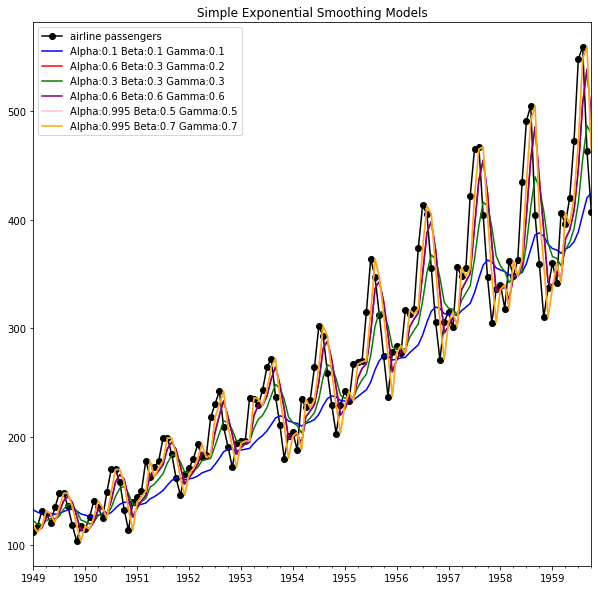

In [11]:
train.plot(color='black', marker="o", label="train", legend=True)

fit1.fittedvalues.plot(color='blue',   label="Alpha:"+str(fit1.params["smoothing_level"])+" Beta:"+str(fit1.params["smoothing_trend"])+" Gamma:"+str(fit1.params["smoothing_seasonal"]), legend=True)
fit2.fittedvalues.plot(color='red',    label="Alpha:"+str(fit2.params["smoothing_level"])+" Beta:"+str(fit2.params["smoothing_trend"])+" Gamma:"+str(fit2.params["smoothing_seasonal"]), legend=True)
fit3.fittedvalues.plot(color='green',  label="Alpha:"+str(fit3.params["smoothing_level"])+" Beta:"+str(fit3.params["smoothing_trend"])+" Gamma:"+str(fit3.params["smoothing_seasonal"]), legend=True)
fit4.fittedvalues.plot(color='purple', label="Alpha:"+str(fit4.params["smoothing_level"])+" Beta:"+str(fit4.params["smoothing_trend"])+" Gamma:"+str(fit4.params["smoothing_seasonal"]), legend=True)
fit5.fittedvalues.plot(color='pink',   label="Alpha:"+str(fit5.params["smoothing_level"])+" Beta:"+str(fit5.params["smoothing_trend"])+" Gamma:"+str(fit5.params["smoothing_seasonal"]), legend=True)
fit6.fittedvalues.plot(color='orange', label="Alpha:"+str(fit6.params["smoothing_level"])+" Beta:"+str(fit6.params["smoothing_trend"])+" Gamma:"+str(fit6.params["smoothing_seasonal"]), legend=True)

plt.title("Simple Exponential Smoothing Models")
plt.show()

## Question 3.1: Apply Autoregression model ([AR](http://www.statsmodels.org/stable/generated/statsmodels.tsa.ar_model.AR.html) API) to the airline dataset and report the prediction accuracy (RMSE and MAE) on the test dataset. Try to play around with the hyper-parameters in the API and see how it impacts the model accuracy. 

In [12]:
# AR example
from statsmodels.tsa.ar_model import AutoReg
from random import random

# fit model
fit1 = AutoReg(train,1).fit()
fit2 = AutoReg(train,2).fit()
fit3 = AutoReg(train,3).fit()
# make prediction
pred1 = fit1.fittedvalues
pred2 = fit2.fittedvalues
pred3 = fit3.fittedvalues

preds   = [pred1, pred2, pred3]
fits    = [fit1, fit2, fit3]
strings = ["Lags: 1","Lags: 2","Lags: 3, Trend: Constant and Time"]
for i in range(3):
    print("Fit", i+1,"|", "Lags: ", i+1)
    print()
    print("rmse:\t" + str(sqrt(mean_squared_error(train[:-1-i],preds[i])))) #size mismatch requires the truncation of the training set here
    print( "mae:\t" + str(mean_absolute_error(train[:-1-i],preds[i])))
    print()

Fit 1 | Lags:  1

rmse:	5.119422490852066
mae:	4.356520581646512

Fit 2 | Lags:  2

rmse:	40.60586591838952
mae:	31.15564394890531

Fit 3 | Lags:  3

rmse:	53.131943902963734
mae:	41.20893423269601



In [13]:
# AR example
from statsmodels.tsa.ar_model import AutoReg
from random import random

# fit model
fit1 = AutoReg(train,1,trend="c").fit()
fit2 = AutoReg(train,1,trend="t").fit()
fit3 = AutoReg(train,1,trend="ct").fit()
fit4 = AutoReg(train,2,trend="t").fit()
fit5 = AutoReg(train,3,trend="ct").fit()
# make prediction
pred1 = fit1.fittedvalues
pred2 = fit2.fittedvalues
pred3 = fit3.fittedvalues
pred4 = fit4.fittedvalues
pred5 = fit5.fittedvalues

preds   = [pred1, pred2, pred3, pred4, pred5]
fits    = [fit1, fit2, fit3, fit4, fit5]
strings = ["Lags: 1, Trend: Constant ","Lags: 1, Trend: Time only","Lags: 1, Trend: Constant and Time","Lags: 2, Trend: Time only","Lags: 3, Trend: Constant and Time"]
for i in range(3):
    print("Fit", i+1,"|", strings[i])
    print()
    print("rmse:\t" + str(sqrt(mean_squared_error(train[:-1],preds[i])))) 
    print(" mae:\t" + str(mean_absolute_error(train[:-1],preds[i])))
    print()
for i in [3,4]:
    print("Fit", i+1,"|", strings[i])
    print()
    print("rmse:\t" + str(sqrt(mean_squared_error(train[:1-i],preds[i])))) 
    print(" mae:\t" + str(mean_absolute_error(train[:1-i],preds[i])))
    print()

Fit 1 | Lags: 1, Trend: Constant 

rmse:	5.119422490852066
 mae:	4.356520581646512

Fit 2 | Lags: 1, Trend: Time only

rmse:	7.458871194069816
 mae:	6.40646433772697

Fit 3 | Lags: 1, Trend: Constant and Time

rmse:	11.75532702442929
 mae:	9.150561747820648

Fit 4 | Lags: 2, Trend: Time only

rmse:	41.41870485018249
 mae:	31.25526653786705

Fit 5 | Lags: 3, Trend: Constant and Time

rmse:	55.00544749376486
 mae:	43.087643548363005



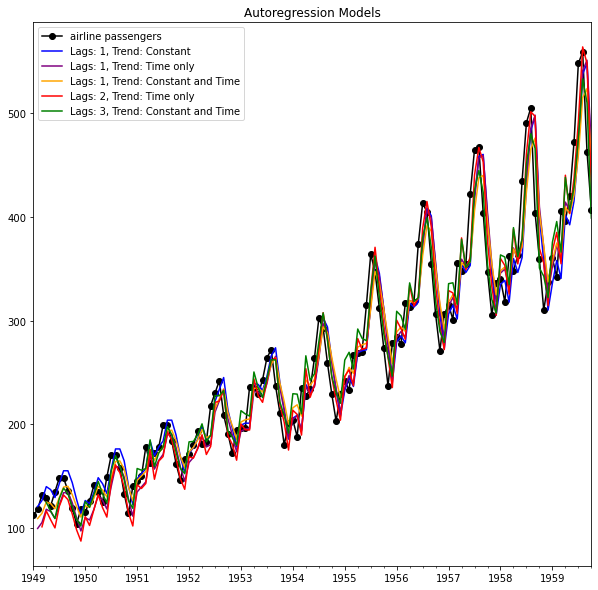

In [14]:
train.plot(color='black', marker="o", label="train", legend=True)

fit1.fittedvalues.plot(color='blue',   label="Lags: 1, Trend: Constant ",         legend=True)
fit2.fittedvalues.plot(color='purple', label="Lags: 1, Trend: Time only",         legend=True)
fit3.fittedvalues.plot(color='orange', label="Lags: 1, Trend: Constant and Time", legend=True)
fit4.fittedvalues.plot(color='red',    label="Lags: 2, Trend: Time only",         legend=True)
fit5.fittedvalues.plot(color='green',  label="Lags: 3, Trend: Constant and Time", legend=True)

plt.title("Autoregression Models")
plt.show()

## Question 3.2: Apply Moving Average model ([ARMA](https://www.statsmodels.org/stable/generated/statsmodels.tsa.arima_model.ARIMA.html) API) to the airline dataset and report the prediction accuracy (RMSE and MAE) on the test dataset. Try to play around with the hyper-parameters in the API and see how it impacts the model accuracy. 

In [15]:
from statsmodels.tsa.arima.model import ARIMA

In [16]:
# MA example

# fit model
fit1 = ARIMA(train,order=(1,0,1), trend=("ct"))
fit2 = ARIMA(train,order=(2,0,1), trend=("ct"))
fit3 = ARIMA(train,order=(3,1,3), trend=("t"))
fit4 = ARIMA(train,order=(4,1,3), trend=("t"))
fit5 = ARIMA(train,order=(5,1,3), trend=("t"))
fit6 = ARIMA(train,order=(6,1,3), trend=("t"))
fit7 = ARIMA(train,order=(8,3,3), trend=("n"))
fit8 = ARIMA(train,order=(9,4,4), trend=("n"))
fits = [fit1,fit2,fit3,fit4,fit5,fit6,fit7,fit8]

#print RMSE and MAE
for i in range(len(fits)):
    pred   = fits[i].fit().fittedvalues # make predictions
    params = [keys+":"+str(value) for keys, value in fits[i].model_orders.items()]
    print("Fit ",i+1, params)                                      #fits[i].model_orders.items())
    print("rmse:\t" + str(sqrt(mean_squared_error(train,pred))))
    print(" mae:\t" + str(mean_absolute_error(train,pred)))
    print()

Fit  1 ['trend:0', 'exog:2', 'ar:1', 'ma:1', 'seasonal_ar:0', 'seasonal_ma:0', 'reduced_ar:1', 'reduced_ma:1', 'exog_variance:0', 'measurement_variance:0', 'variance:1']
rmse:	25.638135552808574
 mae:	21.06168749474602

Fit  2 ['trend:0', 'exog:2', 'ar:2', 'ma:1', 'seasonal_ar:0', 'seasonal_ma:0', 'reduced_ar:2', 'reduced_ma:1', 'exog_variance:0', 'measurement_variance:0', 'variance:1']
rmse:	24.264407299580572
 mae:	19.571057172902805

Fit  3 ['trend:0', 'exog:1', 'ar:3', 'ma:3', 'seasonal_ar:0', 'seasonal_ma:0', 'reduced_ar:3', 'reduced_ma:3', 'exog_variance:0', 'measurement_variance:0', 'variance:1']
rmse:	24.247159955014425
 mae:	18.184753980278696

Fit  4 ['trend:0', 'exog:1', 'ar:4', 'ma:3', 'seasonal_ar:0', 'seasonal_ma:0', 'reduced_ar:4', 'reduced_ma:3', 'exog_variance:0', 'measurement_variance:0', 'variance:1']
rmse:	24.777533728738284
 mae:	19.216975088799035

Fit  5 ['trend:0', 'exog:1', 'ar:5', 'ma:3', 'seasonal_ar:0', 'seasonal_ma:0', 'reduced_ar:5', 'reduced_ma:3', 'exog_

/home/luke/.local/lib/python3.10/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fit  6 ['trend:0', 'exog:1', 'ar:6', 'ma:3', 'seasonal_ar:0', 'seasonal_ma:0', 'reduced_ar:6', 'reduced_ma:3', 'exog_variance:0', 'measurement_variance:0', 'variance:1']
rmse:	23.888002847711665
 mae:	18.517443833113735



/home/luke/.local/lib/python3.10/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fit  7 ['trend:0', 'exog:0', 'ar:8', 'ma:3', 'seasonal_ar:0', 'seasonal_ma:0', 'reduced_ar:8', 'reduced_ma:3', 'exog_variance:0', 'measurement_variance:0', 'variance:1']
rmse:	24.473336588813105
 mae:	18.451628243645473

Fit  8 ['trend:0', 'exog:0', 'ar:9', 'ma:4', 'seasonal_ar:0', 'seasonal_ma:0', 'reduced_ar:9', 'reduced_ma:4', 'exog_variance:0', 'measurement_variance:0', 'variance:1']
rmse:	30.462419331358802
 mae:	21.80057493504637



/home/luke/.local/lib/python3.10/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


----------

## Question 5: After running through various time series models, summarize your findings. 

#### Initially, from viewing just the plot, it looks like the SES models did great, especially the $\alpha$ = 0.99| model. However after viewing the prediction scores it doesn't look like the model did as well as it looked intially, Fit 3 did do somewhat well but a *mae* of ~23.6 but there's surely room for improvement. After apply the ES models the errors started to grow for some hyper parameter combinations but for others it was possible to achieve an accuracy comprable to the SES models pretty easily, I'm confident I could explore this parameter space further to find an even more optimal combination but I couldn't see a way to easily do this without creating an entirely new set of tasks for myself. Further, the plots for the ES models look great, specfically that for Fit 6. I was pretty shocked with how well Autoregression does with the dataset when using just one for Lags and a constant trend but the models that have other hyper parameters still perform incredibly well so long as Lags is one, for Fit 4 and 5 where this isn't the case the accuracies most definetely suffer. Arima appears to fit inbetween the ES and Autoregression in terms of performance if I use the accuracy scores as metric, with so many hyperparameters to vary it was even more difficult to locate ideal values, the parameter space is just so much larger but I found combinations that performed nearly as well as the Autoregression model 'Fit 3', but I couldn't get it to perform anywhere near as well as the Autoregression model 'Fit 1'.

## Question 6. Create a new text cell in your Notebook: Complete a 50-100 word summary (or short description of your thinking in applying this week's learning to the solution) of your experience in this assignment. Include:
                                                                      
* What was your incoming experience with this model, if any? 
* What steps you took, what obstacles you encountered.
* How you link this exercise to real-world, machine learning problem-solving. (What steps were missing? What else do you need to learn?) 
> This summary allows your instructor to know how you are doing and allot points for your effort in thinking and planning, and making connections to real-world work.


#### Like last week and the week before that, and so on, I don't have any incoming experience with any of the models. Of course the concept of regression is familiar but Autoregression for example is entirely new to me. Generally it was all new to me besides what I've learned so far, so naturally I did run into some issues when intially using them but beyond that I had relatively no issues completing this assignment. Like last week the models converge incredibly quick relative to some of the models we've worked with so far. I made full use of the API Documentation when working through the assignment since it was all new, thankfully it was sufficient for my purposes. I could see how this process of exploring alternative approaches to applying a model to obtian marginal performance increases would be done in relatively every field where ML is applied, if the amount of time and effort spent searching for a better approach is less expensive relative to the monetary increases that would result from such an improvement than this is more than a fruitful effort. I apologize for repetitive here by being unable to give a real-world example, however, again this is just due to my lack of experience in the field and in applying ML. I really do hope to apply these skills to a career after this course is finished.